# ACTIVIDAD 3 - MASTER AI - COMPUTER VISION

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# LOAD AND CONVERT TO RGB

imagenes = []

for i in range(20):
    file = f'img/images-{i:04d}.jpg'
    img = cv2.imread(file)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    imagenes.append(img_rgb)

print(len(imagenes))

20


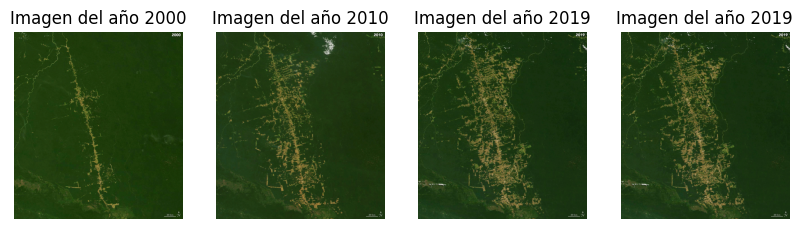

In [37]:
img_2000 = imagenes[0]
img_2004 = imagenes[4]
img_2010 = imagenes[10]
img_2019 = imagenes[19]


fig, ax = plt.subplots(1, 4, figsize=(10, 5))
ax[0].imshow(img_2000)
ax[0].set_title("Imagen del año 2000")
ax[0].axis("off")

ax[1].imshow(img_2010)
ax[1].set_title("Imagen del año 2010")
ax[1].axis("off")

ax[2].imshow(img_2019)
ax[2].set_title("Imagen del año 2019")
ax[2].axis("off")

ax[3].imshow(img_2019)
ax[3].set_title("Imagen del año 2019")
ax[3].axis("off")
plt.show()

1. Implementacion de las funciones necesarias para la actividad

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def segment_image(image, image_clear):
    '''Metodo que segmenta las imagenes con la mascara para las nubes'''
    img = cv2.imread(image)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_clear = cv2.imread(image_clear)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    #segmentacion otsu
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    #obtencion del canal hsv
    img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    img_hsv_clear = cv2.cvtColor(img_clear, cv2.COLOR_RGB2HSV)

    #limites y mascara
    lower_bound = np.array([0, 0, 215])
    upper_bound = np.array([80, 60, 255])
    mask_nubes = cv2.inRange(img_hsv, lower_bound, upper_bound)

    #kernel y operaciones morfologicas sobre la mascara
    kernel = np.ones((9, 9), np.uint8)
    mask_nubes = cv2.dilate(mask_nubes, kernel, iterations=3)
    mask_nubes = cv2.morphologyEx(mask_nubes, cv2.MORPH_CLOSE, kernel, iterations=2)

    #obtencion de imagen con las nubes eliminadas
    mask[mask_nubes == 255] = 0
    mask = img * (mask[:, :, np.newaxis] == 0)

    #implementacion de tecnica de inpainting
    inverted_mask = 1 - mask_nubes
    img_sin_nubes = img * (mask_nubes[:, :, np.newaxis] == 0)

    fill = img_clear * inverted_mask[:, :, np.newaxis]

    inpainted_image = img_sin_nubes + fill

    return img, inpainted_image

In [5]:
def show_segmented_image(original, inpainted):
    '''Metodo para mostrar la imagen segmentada y con la tecnica inpainted aplicada'''
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title("Imagen Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(inpainted, cmap="gray")
    plt.title("Máscara Segmentada (Otsu)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

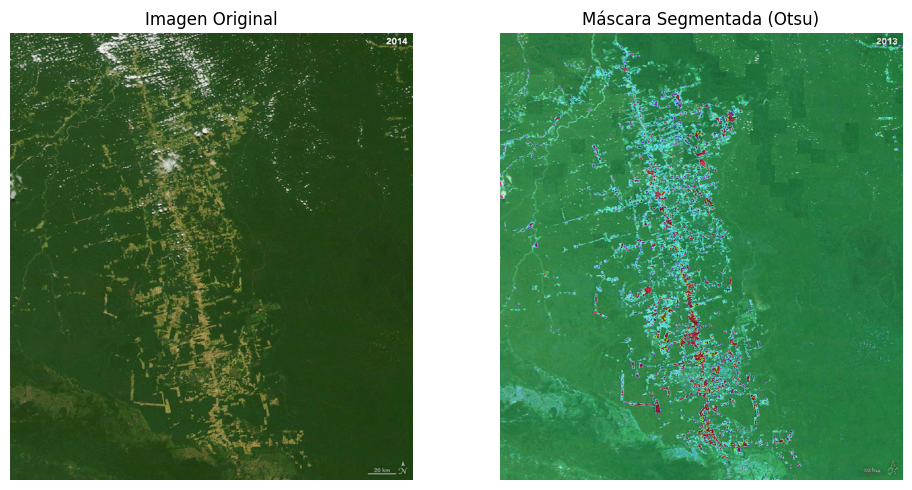

In [6]:
img, inpainted = segment_image("img/images-0014.jpg", 'img/images-0013.jpg')

show_segmented_image(img, inpainted)

In [7]:
def binarize_forest(img):
    '''Binarizacion de la imagen segmentada'''
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    #rango de los tonos verdes
    lower_forest = np.array([25, 30, 20])
    upper_forest = np.array([100, 255, 200])
    
    #mascara que pone en blanco el bosque y en negro el area deforestada
    mask_forest = cv2.inRange(hsv, lower_forest, upper_forest)
    
    return mask_forest


def show_binarized_image(original, binarized):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title("Imagen Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(binarized, cmap="gray")
    plt.title("Imagen Final Binarizada")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

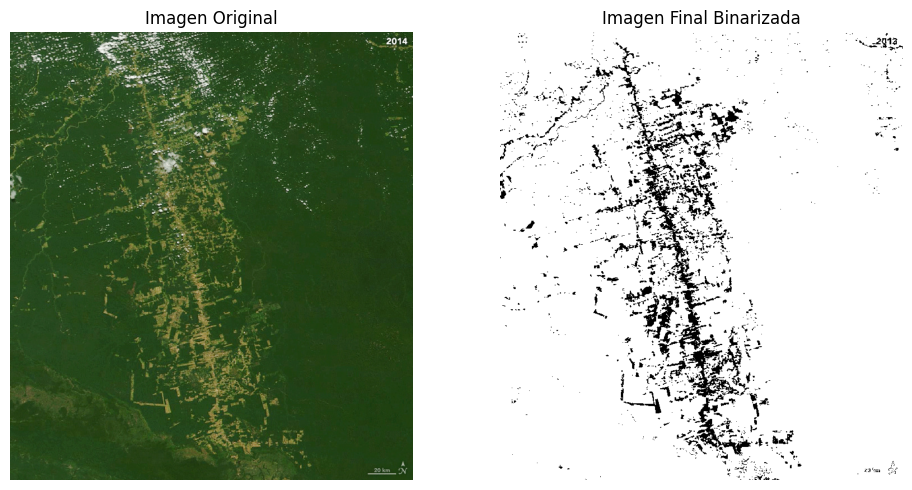

In [8]:
binary_forest = binarize_forest(inpainted)
show_binarized_image(img, binary_forest)  


In [ ]:
def calculo_km (img):
    '''Metodo para calcular el area con escala 51p=20km2'''
    num_pixels_deforestados = np.sum(img == 0)
    area_por_pixel = 20 / (51 ** 2) 
    area_deforestada_km2 = num_pixels_deforestados * area_por_pixel
    return area_deforestada_km2

In [10]:
area_deforestada = calculo_km(binary_forest)
print(f"Área deforestada: {area_deforestada:.2f} km²")

Área deforestada: 307.80 km²


En este punto del codigo ya se han implementado las funcionalidades necesarias para realizar un análisis cuantitativo en cuanto a la evolucion del area deforestada en Jamanxim. A continuación se realizarán los calculos necesarios para obtener esta información.

In [19]:
# AÑO 2000
img, inpainted = segment_image('img/images-0000.jpg', 'img/images-0001.jpg')
bin = binarize_forest(inpainted)
area = calculo_km(bin)
print(f"Área deforestada año 2000: {area:.2f} km²")

Área deforestada año 2000: 70.47 km²


In [20]:
# AÑO 2001
img, inpainted = segment_image('img/images-0001.jpg', 'img/images-0000.jpg')
bin = binarize_forest(inpainted)
area = calculo_km(bin)
print(f"Área deforestada año 2001: {area:.2f} km²")

Área deforestada año 2001: 68.87 km²


In [21]:
# AÑO 2002
img, inpainted = segment_image('img/images-0002.jpg', 'img/images-0001.jpg')
bin = binarize_forest(inpainted)
area = calculo_km(bin)
print(f"Área deforestada año 2002: {area:.2f} km²")

Área deforestada año 2002: 75.80 km²


In [24]:
# AÑO 2003
img, inpainted = segment_image('img/images-0003.jpg', 'img/images-0003.jpg')
bin = binarize_forest(inpainted)
area = calculo_km(bin)
print(f"Área deforestada año 2003: {area:.2f} km²")

Área deforestada año 2003: 99.29 km²


In [23]:
# AÑO 2004
img, inpainted = segment_image('img/images-0004.jpg', 'img/images-0003.jpg')
bin = binarize_forest(inpainted)
area = calculo_km(bin)
print(f"Área deforestada año 2004: {area:.2f} km²")

Área deforestada año 2004: 95.56 km²


In [25]:
# AÑO 2005
img, inpainted = segment_image('img/images-0005.jpg', 'img/images-0003.jpg')
bin = binarize_forest(inpainted)
area = calculo_km(bin)
print(f"Área deforestada año 2005: {area:.2f} km²")

Área deforestada año 2005: 101.81 km²


In [28]:
# AÑO 2006
img, inpainted = segment_image('img/images-0006.jpg', 'img/images-0005.jpg')
bin = binarize_forest(inpainted)
area = calculo_km(bin)
print(f"Área deforestada año 2006: {area:.2f} km²")

Área deforestada año 2006: 127.95 km²


In [29]:
# AÑO 2007
img, inpainted = segment_image('img/images-0007.jpg', 'img/images-0007.jpg')
bin = binarize_forest(inpainted)
area = calculo_km(bin)
print(f"Área deforestada año 2007: {area:.2f} km²")

Área deforestada año 2007: 218.79 km²


In [30]:
# AÑO 2008
img, inpainted = segment_image('img/images-0008.jpg', 'img/images-0007.jpg')
bin = binarize_forest(inpainted)
area = calculo_km(bin)
print(f"Área deforestada año 2008: {area:.2f} km²")

Área deforestada año 2008: 232.66 km²


In [31]:
# AÑO 2009
img, inpainted = segment_image('img/images-0009.jpg', 'img/images-0007.jpg')
bin = binarize_forest(inpainted)
area = calculo_km(bin)
print(f"Área deforestada año 2009: {area:.2f} km²")

Área deforestada año 2009: 230.30 km²


In [33]:
# AÑO 2010
img, inpainted = segment_image('img/images-0010.jpg', 'img/images-0009.jpg')
bin = binarize_forest(inpainted)
area = calculo_km(bin)
print(f"Área deforestada año 2010: {area:.2f} km²")

Área deforestada año 2010: 245.67 km²


In [34]:
# AÑO 2011
img, inpainted = segment_image('img/images-0011.jpg', 'img/images-0010.jpg')
bin = binarize_forest(inpainted)
area = calculo_km(bin)
print(f"Área deforestada año 2011: {area:.2f} km²")

Área deforestada año 2011: 267.64 km²


In [35]:
# AÑO 2012
img, inpainted = segment_image('img/images-0012.jpg', 'img/images-0011.jpg')
bin = binarize_forest(inpainted)
area = calculo_km(bin)
print(f"Área deforestada año 2012: {area:.2f} km²")

Área deforestada año 2012: 289.10 km²


In [37]:
# AÑO 2013
img, inpainted = segment_image('img/images-0013.jpg', 'img/images-0013.jpg')
bin = binarize_forest(inpainted)
area = calculo_km(bin)
print(f"Área deforestada año 2013: {area:.2f} km²")

Área deforestada año 2013: 282.09 km²


In [38]:
# AÑO 2014
img, inpainted = segment_image('img/images-0014.jpg', 'img/images-0013.jpg')
bin = binarize_forest(inpainted)
area = calculo_km(bin)
print(f"Área deforestada año 2014: {area:.2f} km²")

Área deforestada año 2014: 307.80 km²


In [40]:
# AÑO 2015
img, inpainted = segment_image('img/images-0015.jpg', 'img/images-0016.jpg')
bin = binarize_forest(inpainted)
area = calculo_km(bin)
print(f"Área deforestada año 2015: {area:.2f} km²")

Área deforestada año 2015: 272.76 km²


In [41]:
# AÑO 2016
img, inpainted = segment_image('img/images-0016.jpg', 'img/images-0015.jpg')
bin = binarize_forest(inpainted)
area = calculo_km(bin)
print(f"Área deforestada año 2016: {area:.2f} km²")

Área deforestada año 2016: 272.13 km²


In [42]:
# AÑO 2017
img, inpainted = segment_image('img/images-0017.jpg', 'img/images-0016.jpg')
bin = binarize_forest(inpainted)
area = calculo_km(bin)
print(f"Área deforestada año 2017: {area:.2f} km²")

Área deforestada año 2017: 363.94 km²


In [43]:
# AÑO 2018
img, inpainted = segment_image('img/images-0018.jpg', 'img/images-0017.jpg')
bin = binarize_forest(inpainted)
area = calculo_km(bin)
print(f"Área deforestada año 2018: {area:.2f} km²")

Área deforestada año 2018: 364.07 km²


In [44]:
# AÑO 2019
img, inpainted = segment_image('img/images-0019.jpg', 'img/images-0018.jpg')
bin = binarize_forest(inpainted)
area = calculo_km(bin)
print(f"Área deforestada año 2019: {area:.2f} km²")

Área deforestada año 2019: 336.76 km²
